In [1]:
# ============================================================
# NOTEBOOK 1: CSi-GAN Training (WLI <-> NBI Translation)
# Runtime: GPU (P100 or 2xT4)
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# CONFIG — all values directly from paper
# ============================================================

class CFG:
    # Paths
    DATASET_PATH = "/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue"
    ROOT_PATH = "/kaggle/input/datasets/kathan1803/ebt-research-processed-data"
    OUTPUT_PATH = "/kaggle/working/"

    # Hyperparameters
    IMG_SIZE    = 256
    BATCH_SIZE  = 1          # CycleGAN standard; paper uses batch=1
    EPOCHS      = 150        # Paper trains for 150 epochs
    LR          = 2e-4       # Paper: initial lr = 2e-4
    LAMBDA_SIM  = 2.0        # Paper: λ1 = λ2 = 2.0
    LAMBDA_CYC  = 1.0        # Paper: λ3 = λ4 = 1.0
    
    # LR schedule: constant for first 100 epochs,
    # then linear decay to 0 over remaining 50 (paper Section III-E)
    LR_DECAY_START = 100
    LR_DECAY_END   = 150

    # Monitoring
    MONITOR_FREQ = 10        # Save sample images every N epochs
    SAVE_FREQ    = 25        # Save weights every N epochs

    # GAN architecture
    N_RESIDUAL_BLOCKS = 9    # Standard for 256x256 input

    AUTOTUNE = tf.data.AUTOTUNE

os.makedirs(CFG.OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(CFG.OUTPUT_PATH, "gan_samples"), exist_ok=True)
os.makedirs(os.path.join(CFG.OUTPUT_PATH, "gan_weights"), exist_ok=True)

2026-02-24 07:12:19.185079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771917139.206565     286 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771917139.213063     286 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771917139.230141     286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771917139.230165     286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771917139.230167     286 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================================
# GPU SETUP & VERIFICATION
# ============================================================

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs available: {len(gpus)}")
    for gpu in gpus:
        print(f"  {gpu}")
else:
    print("WARNING: No GPU found")

# Use MirroredStrategy if 2 GPUs available (Kaggle 2xT4)
# Falls back to default strategy for single GPU
# if len(gpus) > 1:
#     strategy = tf.distribute.MirroredStrategy()
#     print(f"Using MirroredStrategy across {strategy.num_replicas_in_sync} GPUs")
#     # Note: with 2 GPUs and batch=1, effective batch is still 1 per GPU
#     # CycleGAN is sensitive to this — keep BATCH_SIZE=1 per replica
# else:
#     strategy = tf.distribute.get_strategy()
#     print("Using default (single GPU) strategy")

strategy = tf.distribute.get_strategy()  # always single-device
print("Using single-GPU strategy (required for batch_size=1 CycleGAN)")

GPUs available: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Using single-GPU strategy (required for batch_size=1 CycleGAN)


In [3]:
# ============================================================
# DATA LOADING FROM CSVs (patient-wise split)
# ============================================================

def filter_existing(df, base_path):
    mask = df['full_path'].apply(
        lambda p: os.path.exists(os.path.join(base_path, p.strip()))
    )
    missing = (~mask).sum()
    if missing:
        print(f"Dropping {missing} rows with missing files")
    return df[mask].reset_index(drop=True)

wli_train_df = pd.read_csv(os.path.join(CFG.ROOT_PATH, "nb1_wli_train.csv"))
nbi_train_df = pd.read_csv(os.path.join(CFG.ROOT_PATH, "nb1_nbi_train.csv"))

# filter to only files that exist
wli_train_df = filter_existing(wli_train_df, CFG.DATASET_PATH)
nbi_train_df = filter_existing(nbi_train_df, CFG.DATASET_PATH)

wli_paths = [
    os.path.join(CFG.DATASET_PATH, p)
    for p in wli_train_df['full_path']
]

nbi_paths = [
    os.path.join(CFG.DATASET_PATH, p)
    for p in nbi_train_df['full_path']
]

print(f"WLI training images : {len(wli_paths)}")
print(f"NBI training images : {len(nbi_paths)}")
print(f"\nWLI class distribution:")
print(wli_train_df['tissue type'].value_counts().to_dict())
print(f"\nNBI class distribution:")
print(nbi_train_df['tissue type'].value_counts().to_dict())

# Verify a few paths exist
missing = [p for p in wli_paths[:5] + nbi_paths[:5] if not os.path.exists(p)]
if missing:
    print(f"\nWARNING: {len(missing)} paths not found. Check DATASET_PATH.")
    for p in missing:
        print(f"  MISSING: {p}")
else:
    print("\nPath check: all sampled paths exist. ✓")

Dropping 31 rows with missing files
WLI training images : 912
NBI training images : 243

WLI class distribution:
{'LGC': 320, 'HGC': 299, 'NST': 228, 'NTL': 65}

NBI class distribution:
{'LGC': 112, 'NST': 55, 'HGC': 47, 'NTL': 29}

Path check: all sampled paths exist. ✓


In [4]:
# ============================================================
# DATA PIPELINE
# FIX 1: tf.image.decode_image returns unknown-rank tensors.
#         We must set the rank immediately after decoding so
#         every downstream op (resize, pad, conv) can infer shapes.
# FIX 2: Use tf.ensure_shape AFTER batching to guarantee the
#         full [B, H, W, C] shape is known at graph-trace time.
# ============================================================

def load_and_preprocess(image_path, augment=True):
    img = tf.io.read_file(image_path)

    # decode_image can handle jpg/png/bmp but returns UNKNOWN rank.
    # expand_animations=False collapses GIF frames but does NOT fix rank.
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    # *** CRITICAL FIX: set the rank so TF knows this is a 3-D tensor ***
    img.set_shape([None, None, 3])

    img = tf.image.resize(img, [CFG.IMG_SIZE, CFG.IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)

    # Now spatial dims are fully known (rank is already set above)
    img = tf.ensure_shape(img, [CFG.IMG_SIZE, CFG.IMG_SIZE, 3])
    return img


def build_dataset(paths, augment=True):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.shuffle(
        buffer_size=len(paths),
        reshuffle_each_iteration=True,
    )
    ds = ds.repeat()
    ds = ds.map(
        lambda p: load_and_preprocess(p, augment=augment),
        num_parallel_calls=CFG.AUTOTUNE,
    )
    ds = ds.batch(CFG.BATCH_SIZE, drop_remainder=True)

    # *** FIX: lock in the full 4-D shape AFTER batching ***
    ds = ds.map(
        lambda x: tf.ensure_shape(
            x, [CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3]
        )
    )
    ds = ds.prefetch(CFG.AUTOTUNE)
    return ds


wli_dataset = build_dataset(wli_paths, augment=True)
nbi_dataset = build_dataset(nbi_paths, augment=True)

steps_per_epoch = min(len(wli_paths), len(nbi_paths))

train_dataset = tf.data.Dataset.zip((wli_dataset, nbi_dataset))

print(f"WLI images      : {len(wli_paths)}")
print(f"NBI images      : {len(nbi_paths)}")
print(f"Steps per epoch : {steps_per_epoch}")
print(f"Total steps     : {steps_per_epoch * CFG.EPOCHS}")

# Verify shapes before training
print("\nVerifying batch shapes...")
for (wli_batch, nbi_batch) in train_dataset.take(3):
    assert wli_batch.shape == (CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3), \
        f"Bad WLI shape: {wli_batch.shape}"
    assert nbi_batch.shape == (CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3), \
        f"Bad NBI shape: {nbi_batch.shape}"
print(f"  WLI batch shape: {wli_batch.shape} ✓")
print(f"  NBI batch shape: {nbi_batch.shape} ✓")

I0000 00:00:1771917149.577832     286 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


WLI images      : 912
NBI images      : 243
Steps per epoch : 243
Total steps     : 36450

Verifying batch shapes...
  WLI batch shape: (1, 256, 256, 3) ✓
  NBI batch shape: (1, 256, 256, 3) ✓


In [5]:
# ============================================================
# CUSTOM LAYERS
# FIX 3: ReflectionPadding2D must propagate shapes through
#         both compute_output_shape AND call (via set_shape)
#         so that the residual Add() sees matching shapes.
# ============================================================

class ReflectionPadding2D(layers.Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        super().__init__(**kwargs)
        self.padding = tuple(padding)

    def call(self, inputs):
        pad_h, pad_w = self.padding
        result = tf.pad(
            inputs,
            [[0, 0], [pad_h, pad_h], [pad_w, pad_w], [0, 0]],
            mode='REFLECT',
        )
        # *** FIX: explicitly propagate static shape after tf.pad ***
        # tf.pad can lose static shape info for the batch dimension
        in_shape = inputs.shape
        new_h = (in_shape[1] + 2 * pad_h) if in_shape[1] is not None else None
        new_w = (in_shape[2] + 2 * pad_w) if in_shape[2] is not None else None
        result.set_shape([in_shape[0], new_h, new_w, in_shape[3]])
        return result

    def compute_output_shape(self, input_shape):
        pad_h, pad_w = self.padding
        # *** FIX: handle None (dynamic) batch dimension properly ***
        batch = input_shape[0]   # stays None if dynamic — that is correct
        h = (input_shape[1] + 2 * pad_h) if input_shape[1] is not None else None
        w = (input_shape[2] + 2 * pad_w) if input_shape[2] is not None else None
        return (batch, h, w, input_shape[3])

    def get_config(self):
        config = super().get_config()
        config.update({'padding': self.padding})
        return config

In [6]:
# ============================================================
# MODEL ARCHITECTURE
# Standard CycleGAN generator (ResNet-based, 9 blocks) and PatchGAN discriminator
# ============================================================

# --- Instance Normalization ---
# CycleGAN uses Instance Normalization, not BatchNorm.
# This is important: BatchNorm with batch=1 degenerates.
# tf.keras doesn't have InstanceNorm natively

class InstanceNormalization(layers.Layer):
    """
    Instance Normalization layer.
    Normalizes each sample independently across spatial dimensions.
    Essential for CycleGAN with batch_size=1.
    """
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma', shape=(input_shape[-1],),
            initializer='ones', trainable=True)
        self.beta = self.add_weight(
            name='beta', shape=(input_shape[-1],),
            initializer='zeros', trainable=True)

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x_norm = (x - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * x_norm + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config


# --- Residual Block (with Instance Normalization) ---
def residual_block(x, filters=256):
    """
    Residual block as used in the CycleGAN generator.
    Uses reflection padding to reduce artifacts at image borders.
    """
    residual = x

    x = ReflectionPadding2D((1,1))(x)
    x = layers.Conv2D(filters, 3, padding='valid', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    x = ReflectionPadding2D((1,1))(x)
    x = layers.Conv2D(filters, 3, padding='valid', use_bias=False)(x)
    x = InstanceNormalization()(x)

    return layers.Add()([residual, x])

# --- Generator ---
def build_generator(name="generator"):
    """
    ResNet-based generator with 9 residual blocks (for 256x256).
    Architecture: Paper Section III-B, based on CycleGAN [60].
    c7s1-64, d128, d256, R256 x9, u128, u64, c7s1-3
    """
    inputs = layers.Input(shape=(CFG.IMG_SIZE, CFG.IMG_SIZE, 3), name='input')

    # Initial convolution block (c7s1-64)
    x = ReflectionPadding2D((3,3))(inputs)
    x = layers.Conv2D(64, 7, padding='valid', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    # Downsampling (d128, d256)
    for filters in [128, 256]:
        x = layers.Conv2D(
            filters, 3, strides=2, padding='same', use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.ReLU()(x)

    # Residual blocks (R256 x9)
    for _ in range(CFG.N_RESIDUAL_BLOCKS):
        x = residual_block(x, 256)

    # Upsampling (u128, u64)
    for filters in [128, 64]:
        x = layers.Conv2DTranspose(
            filters, 3, strides=2, padding='same', use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.ReLU()(x)

    # Output convolution (c7s1-3)
    x = ReflectionPadding2D((3,3))(x)
    x = layers.Conv2D(3, 7, padding='valid', activation='tanh')(x)

    return keras.Model(inputs, x, name=name)


# --- PatchGAN Discriminator ---
def build_discriminator(name="discriminator"):
    """
    70x70 PatchGAN discriminator.
    Classifies whether overlapping 70x70 patches are real or fake.
    Architecture: Paper Section III-B, standard CycleGAN discriminator.
    C64-C128-C256-C512
    """
    inputs = layers.Input(shape=(CFG.IMG_SIZE, CFG.IMG_SIZE, 3), name='input')

    # C64 (no normalization on first layer)
    x = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(0.2)(x)

    # C128, C256, C512
    for filters in [128, 256, 512]:
        stride = 2 if filters != 512 else 1
        x = layers.Conv2D(filters, 4, strides=stride, padding='same',
                          use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)

    # Final patch prediction
    x = layers.Conv2D(1, 4, strides=1, padding='same')(x)

    return keras.Model(inputs, x, name=name)

In [7]:
# ============================================================
# SIMILARITY LOSS
# Lsim = 1 - SSIM(original, translated)
# Forces generator to preserve fine-grain pathological details which are critical for diagnosis
# ============================================================

def ssim_loss(img_original, img_translated):
    """
    Structural Similarity loss: 1 - SSIM.
    Inputs in [-1, 1]; converted to [0, 1] for tf.image.ssim.
    """
    orig_01  = (img_original  + 1.0) / 2.0
    trans_01 = (img_translated + 1.0) / 2.0
    ssim_val = tf.image.ssim(orig_01, trans_01, max_val=1.0)
    ssim_val = tf.reshape(ssim_val, [-1])
    return tf.reduce_mean(1.0 - ssim_val)

In [8]:
# ============================================================
# CSi-GAN MODEL
# L = Ladv(G_AB,D_A) + Ladv(G_BA,D_B)
#   + λ1·Lsim(G_AB) + λ2·Lsim(G_BA)
#   + λ3·Lcyc(A->B->A) + λ4·Lcyc(B->A->B)
# ============================================================

class CSiGAN(keras.Model):

    def __init__(self, G_AB, G_BA, D_A, D_B,
                 lambda_sim=2.0, lambda_cyc=1.0):
        super().__init__()
        self.G_AB = G_AB
        self.G_BA = G_BA
        self.D_A  = D_A
        self.D_B  = D_B
        self.lambda_sim = lambda_sim
        self.lambda_cyc = lambda_cyc

    def compile(self, G_AB_opt, G_BA_opt, D_A_opt, D_B_opt):
        super().compile()
        self.G_AB_opt = G_AB_opt
        self.G_BA_opt = G_BA_opt
        self.D_A_opt  = D_A_opt
        self.D_B_opt  = D_B_opt
        self.mse = keras.losses.MeanSquaredError()

    def discriminator_loss(self, real_output, fake_output):
        real_loss = self.mse(tf.ones_like(real_output),  real_output)
        fake_loss = self.mse(tf.zeros_like(fake_output), fake_output)
        return (real_loss + fake_loss) * 0.5

    def generator_adv_loss(self, fake_output):
        return self.mse(tf.ones_like(fake_output), fake_output)

    def cycle_loss(self, real, reconstructed):
        return tf.reduce_mean(tf.abs(real - reconstructed))

    @tf.function
    def train_step(self, batch):
        real_A, real_B = batch

        # *** FIX: enforce shape at the start of the traced function ***
        real_A = tf.ensure_shape(
            real_A, [CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3]
        )
        real_B = tf.ensure_shape(
            real_B, [CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3]
        )

        with tf.GradientTape(persistent=True) as tape:

            # Forward pass
            fake_B   = self.G_AB(real_A, training=True)
            fake_A   = self.G_BA(real_B, training=True)
            cycled_A = self.G_BA(fake_B, training=True)
            cycled_B = self.G_AB(fake_A, training=True)

            # Discriminator outputs
            disc_real_A = self.D_A(real_A, training=True)
            disc_fake_A = self.D_A(fake_A, training=True)
            disc_real_B = self.D_B(real_B, training=True)
            disc_fake_B = self.D_B(fake_B, training=True)

            # Generator losses
            adv_G_AB = self.generator_adv_loss(disc_fake_B)
            adv_G_BA = self.generator_adv_loss(disc_fake_A)

            cyc_A  = self.cycle_loss(real_A, cycled_A)
            cyc_B  = self.cycle_loss(real_B, cycled_B)

            sim_AB = ssim_loss(real_A, fake_B)
            sim_BA = ssim_loss(real_B, fake_A)

            G_AB_loss = (adv_G_AB
                         + self.lambda_sim * sim_AB
                         + self.lambda_cyc * cyc_A)

            G_BA_loss = (adv_G_BA
                         + self.lambda_sim * sim_BA
                         + self.lambda_cyc * cyc_B)

            # Discriminator losses
            D_A_loss = self.discriminator_loss(disc_real_A, disc_fake_A)
            D_B_loss = self.discriminator_loss(disc_real_B, disc_fake_B)

        # Gradients
        G_AB_grads = tape.gradient(G_AB_loss, self.G_AB.trainable_variables)
        G_BA_grads = tape.gradient(G_BA_loss, self.G_BA.trainable_variables)
        D_A_grads  = tape.gradient(D_A_loss,  self.D_A.trainable_variables)
        D_B_grads  = tape.gradient(D_B_loss,  self.D_B.trainable_variables)

        self.G_AB_opt.apply_gradients(
            [(g, v) for g, v in zip(G_AB_grads, self.G_AB.trainable_variables)
             if g is not None]
        )
        self.G_BA_opt.apply_gradients(
            [(g, v) for g, v in zip(G_BA_grads, self.G_BA.trainable_variables)
             if g is not None]
        )
        self.D_A_opt.apply_gradients(
            [(g, v) for g, v in zip(D_A_grads, self.D_A.trainable_variables)
             if g is not None]
        )
        self.D_B_opt.apply_gradients(
            [(g, v) for g, v in zip(D_B_grads, self.D_B.trainable_variables)
             if g is not None]
        )

        del tape

        return {
            "G_AB_loss": G_AB_loss,
            "G_BA_loss": G_BA_loss,
            "D_A_loss":  D_A_loss,
            "D_B_loss":  D_B_loss,
            "cyc_loss":  cyc_A + cyc_B,
            "sim_loss":  sim_AB + sim_BA,
        }

In [9]:
# ============================================================
# LEARNING RATE SCHEDULE
# Constant at 2e-4 for first 100 epochs, then linear decay to 0 over epochs 100-150
# ============================================================

def lr_schedule(epoch, lr):
    if epoch < CFG.LR_DECAY_START:
        return CFG.LR
    else:
        decay_steps = CFG.LR_DECAY_END - CFG.LR_DECAY_START
        progress    = (epoch - CFG.LR_DECAY_START) / decay_steps
        return float(CFG.LR * (1.0 - progress))

print("LR schedule check:")
for ep in [0, 50, 99, 100, 125, 149]:
    print(f"  Epoch {ep:>3}: lr = {lr_schedule(ep, None):.2e}")

LR schedule check:
  Epoch   0: lr = 2.00e-04
  Epoch  50: lr = 2.00e-04
  Epoch  99: lr = 2.00e-04
  Epoch 100: lr = 2.00e-04
  Epoch 125: lr = 1.00e-04
  Epoch 149: lr = 4.00e-06


In [10]:
# ============================================================
# CALLBACKS
# ============================================================

class GANMonitor(keras.callbacks.Callback):
    """
    Saves a 2x4 grid of translation samples every MONITOR_FREQ epochs.
    Row 1: WLI -> NBI -> reconstructed WLI
    Row 2: NBI -> WLI -> reconstructed NBI
    """
    def __init__(self, sample_wli, sample_nbi, save_dir, freq=10):
        super().__init__()
        # Keep single images (batch of 1) for display
        self.sample_wli = sample_wli
        self.sample_nbi = sample_nbi
        self.save_dir   = save_dir
        self.freq       = freq

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.freq != 0:
            return

        fake_nbi    = self.model.G_AB(self.sample_wli, training=False)
        fake_wli    = self.model.G_BA(self.sample_nbi, training=False)
        cycled_wli  = self.model.G_BA(fake_nbi, training=False)
        cycled_nbi  = self.model.G_AB(fake_wli, training=False)

        def to_display(t):
            # Convert from [-1,1] tensor to [0,1] numpy for imshow
            return ((t[0].numpy() + 1.0) / 2.0).clip(0, 1)

        fig, axes = plt.subplots(2, 4, figsize=(18, 9))
        fig.suptitle(f'Epoch {epoch+1}', fontsize=14)

        row1 = [
            (self.sample_wli, 'Real WLI'),
            (fake_nbi,        'Fake NBI (G_AB)'),
            (cycled_wli,      'Cycled WLI (G_BA∘G_AB)'),
            (self.sample_nbi, 'Real NBI'),
        ]
        row2 = [
            (self.sample_nbi, 'Real NBI'),
            (fake_wli,        'Fake WLI (G_BA)'),
            (cycled_nbi,      'Cycled NBI (G_AB∘G_BA)'),
            (self.sample_wli, 'Real WLI'),
        ]

        for ax, (img_tensor, title) in zip(axes[0], row1):
            ax.imshow(to_display(img_tensor))
            ax.set_title(title, fontsize=9)
            ax.axis('off')
        for ax, (img_tensor, title) in zip(axes[1], row2):
            ax.imshow(to_display(img_tensor))
            ax.set_title(title, fontsize=9)
            ax.axis('off')

        plt.tight_layout()
        save_path = os.path.join(self.save_dir, f"epoch_{epoch+1:03d}.png")
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close()
        print(f"  [Monitor] Saved translation samples -> {save_path}")


class WeightSaver(keras.callbacks.Callback):
    """Saves all 4 model weights every SAVE_FREQ epochs and at end."""
    def __init__(self, save_dir, freq=25):
        super().__init__()
        self.save_dir = save_dir
        self.freq     = freq

    def _save(self, epoch_tag):
        for model, name in [
            (self.model.G_AB, "G_AB"),
            (self.model.G_BA, "G_BA"),
            (self.model.D_A,  "D_A"),
            (self.model.D_B,  "D_B"),
        ]:
            model.save_weights(
                os.path.join(self.save_dir, f"{name}_{epoch_tag}.weights.h5"))
        print(f"  [Saver] Weights saved: {epoch_tag}")

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.freq == 0:
            self._save(f"epoch{epoch+1:03d}")

    def on_train_end(self, logs=None):
        self._save("final")


class LossTracker(keras.callbacks.Callback):
    """Prints a clean summary every 10 epochs."""
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1:>3}/{CFG.EPOCHS} | "
                f"G_AB: {logs['G_AB_loss']:.4f} | "
                f"G_BA: {logs['G_BA_loss']:.4f} | "
                f"D_A: {logs['D_A_loss']:.4f} | "
                f"D_B: {logs['D_B_loss']:.4f} | "
                f"Cyc: {logs['cyc_loss']:.4f} | "
                f"Sim: {logs['sim_loss']:.4f}"
            )

In [11]:
# ============================================================
# BUILD MODELS
# ============================================================

with strategy.scope():
    G_AB = build_generator(name="G_AB")
    G_BA = build_generator(name="G_BA")
    D_A  = build_discriminator(name="D_A")
    D_B  = build_discriminator(name="D_B")

    # *** FIX: explicitly build every sub-model so shapes are resolved ***
    dummy_input = tf.zeros([CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3])
    _ = G_AB(dummy_input)
    _ = G_BA(dummy_input)
    _ = D_A(dummy_input)
    _ = D_B(dummy_input)

    csi_gan = CSiGAN(
        G_AB, G_BA, D_A, D_B,
        lambda_sim=CFG.LAMBDA_SIM,
        lambda_cyc=CFG.LAMBDA_CYC,
    )

    csi_gan.compile(
        G_AB_opt=keras.optimizers.Adam(CFG.LR, beta_1=0.5, beta_2=0.999),
        G_BA_opt=keras.optimizers.Adam(CFG.LR, beta_1=0.5, beta_2=0.999),
        D_A_opt =keras.optimizers.Adam(CFG.LR, beta_1=0.5, beta_2=0.999),
        D_B_opt =keras.optimizers.Adam(CFG.LR, beta_1=0.5, beta_2=0.999),
    )

print("Generator G_AB:")
G_AB.summary()
print(f"\nGenerator params: {G_AB.count_params():,}")
print(f"Discriminator params: {D_A.count_params():,}")

I0000 00:00:1771917152.679914     286 cuda_dnn.cc:529] Loaded cuDNN version 91002


Generator G_AB:


Model: "G_AB"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reflection_padding… │ (None, 262, 262,  │          0 │ input[0][0]       │
│ (ReflectionPadding… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      9,408 │ reflection_paddi… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (InstanceNormaliza… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ instance_normali… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     73,728 │ re_lu[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (InstanceNormaliza… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ instance_normali… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    294,912 │ re_lu_1[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (InstanceNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ instance_normali… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reflection_padding… │ (None, 66, 66,    │          0 │ re_lu_2[0][0]     │
│ (ReflectionPadding… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    589,824 │ reflection_paddi… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (InstanceNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ instance_normali… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reflection_padding… │ (None, 66, 66,    │          0 │ re_lu_3[0][0]     │
│ (ReflectionPadding… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    589,824 │ reflection_paddi

 Total params: 11,383,427 (43.42 MB)

 Trainable params: 11,383,427 (43.42 MB)

 Non-trainable params: 0 (0.00 B)


Generator params: 11,383,427
Discriminator params: 2,765,633


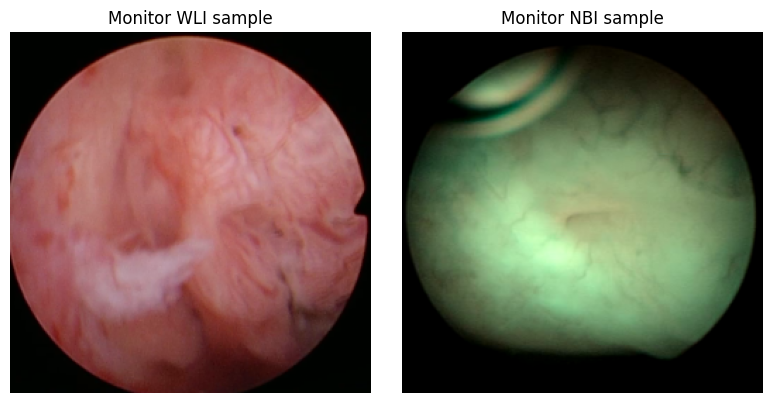

In [12]:
# ============================================================
# SAMPLE IMAGES FOR MONITORING
# Pick one fixed WLI and one fixed NBI image — same ones used throughout training so you can track quality improvement
# ============================================================

# Get first batch from each domain (batch_size=1 so this is 1 image)
sample_wli_batch = next(iter(wli_dataset))
sample_nbi_batch = next(iter(nbi_dataset))

# Verify monitor samples have correct shape
assert sample_wli_batch.shape == (CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3), \
    f"Monitor WLI bad shape: {sample_wli_batch.shape}"
assert sample_nbi_batch.shape == (CFG.BATCH_SIZE, CFG.IMG_SIZE, CFG.IMG_SIZE, 3), \
    f"Monitor NBI bad shape: {sample_nbi_batch.shape}"

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(((sample_wli_batch[0].numpy() + 1) / 2).clip(0, 1))
axes[0].set_title("Monitor WLI sample")
axes[0].axis('off')
axes[1].imshow(((sample_nbi_batch[0].numpy() + 1) / 2).clip(0, 1))
axes[1].set_title("Monitor NBI sample")
axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_PATH, "monitor_samples.png"), dpi=100)
plt.show()

In [13]:
# ============================================================
# CALLBACKS LIST
# ============================================================

callbacks = [
    GANMonitor(
        sample_wli=sample_wli_batch,
        sample_nbi=sample_nbi_batch,
        save_dir=os.path.join(CFG.OUTPUT_PATH, "gan_samples"),
        freq=CFG.MONITOR_FREQ,
    ),
    WeightSaver(
        save_dir=os.path.join(CFG.OUTPUT_PATH, "gan_weights"),
        freq=CFG.SAVE_FREQ,
    ),
    LossTracker(),
    keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    keras.callbacks.CSVLogger(
        os.path.join(CFG.OUTPUT_PATH, "gan_training_log.csv"),
        append=False,
    ),
]

In [14]:
# ============================================================
# TRAIN
# ============================================================

print(f"\nStarting CSi-GAN training:")
print(f"  Epochs        : {CFG.EPOCHS}")
print(f"  Batch size    : {CFG.BATCH_SIZE}")
print(f"  LR            : {CFG.LR} (decay from epoch {CFG.LR_DECAY_START})")
print(f"  Lambda sim    : {CFG.LAMBDA_SIM}")
print(f"  Lambda cyc    : {CFG.LAMBDA_CYC}")
print(f"  WLI images    : {len(wli_paths)}")
print(f"  NBI images    : {len(nbi_paths)}")
print(f"  Steps/epoch   : {steps_per_epoch}")
print()

history = csi_gan.fit(
    train_dataset,
    epochs=CFG.EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
    verbose=0,
)


Starting CSi-GAN training:
  Epochs        : 150
  Batch size    : 1
  LR            : 0.0002 (decay from epoch 100)
  Lambda sim    : 2.0
  Lambda cyc    : 1.0
  WLI images    : 912
  NBI images    : 243
  Steps/epoch   : 243



I0000 00:00:1771917185.347994     346 service.cc:152] XLA service 0x7f0ca8003090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771917185.348028     346 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771917210.566063     346 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  [Monitor] Saved translation samples -> /kaggle/working/gan_samples/epoch_010.png
Epoch  10/150 | G_AB: 0.5010 | G_BA: 0.5578 | D_A: 0.2834 | D_B: 0.2698 | Cyc: 0.2057 | Sim: 0.1766
  [Monitor] Saved translation samples -> /kaggle/working/gan_samples/epoch_020.png
Epoch  20/150 | G_AB: 0.8038 | G_BA: 0.4942 | D_A: 0.2299 | D_B: 0.2343 | Cyc: 0.1851 | Sim: 0.1518
  [Saver] Weights saved: epoch025
  [Monitor] Saved translation samples -> /kaggle/working/gan_samples/epoch_030.png
Epoch  30/150 | G_AB: 0.4462 | G_BA: 0.4625 | D_A: 0.2716 | D_B: 0.2016 | Cyc: 0.2205 | Sim: 0.1044
  [Monitor] Saved translation samples -> /kaggle/working/gan_samples/epoch_040.png
Epoch  40/150 | G_AB: 0.5849 | G_BA: 0.7441 | D_A: 0.2707 | D_B: 0.1142 | Cyc: 0.3263 | Sim: 0.2569
  [Monitor] Saved translation samples -> /kaggle/working/gan_samples/epoch_050.png
  [Saver] Weights saved: epoch050
Epoch  50/150 | G_AB: 0.9669 | G_BA: 0.6180 | D_A: 0.1230 | D_B: 0.1393 | Cyc: 0.2621 | Sim: 0.2481
  [Monitor] Saved

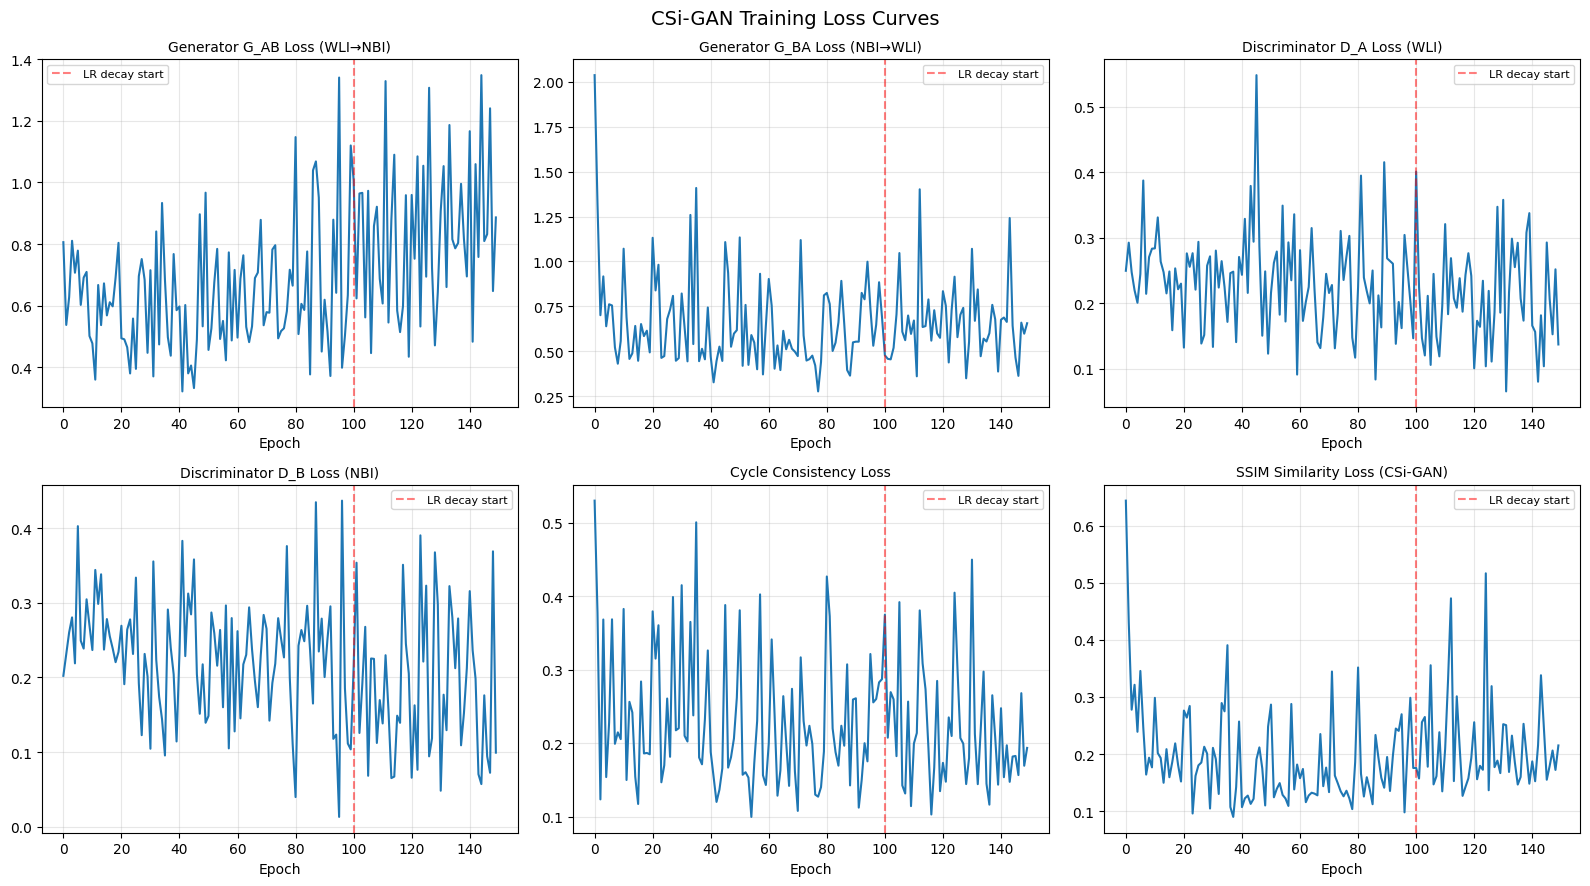


Training complete.
Outputs saved to: /kaggle/working/
Files ready for Notebook 2 and 3:
  gan_weights/G_AB_final.h5
  gan_weights/G_BA_final.h5
  gan_weights/D_A_final.h5
  gan_weights/D_B_final.h5
  gan_training_log.csv
  gan_samples/epoch_*.png  (visual quality check)


In [15]:
# ============================================================
# POST-TRAINING: PLOT LOSS CURVES
# ============================================================

log_df = pd.read_csv(os.path.join(CFG.OUTPUT_PATH, "gan_training_log.csv"))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('CSi-GAN Training Loss Curves', fontsize=14)

plots = [
    ('G_AB_loss', 'Generator G_AB Loss (WLI→NBI)', axes[0, 0]),
    ('G_BA_loss', 'Generator G_BA Loss (NBI→WLI)', axes[0, 1]),
    ('D_A_loss',  'Discriminator D_A Loss (WLI)',   axes[0, 2]),
    ('D_B_loss',  'Discriminator D_B Loss (NBI)',   axes[1, 0]),
    ('cyc_loss',  'Cycle Consistency Loss',          axes[1, 1]),
    ('sim_loss',  'SSIM Similarity Loss (CSi-GAN)', axes[1, 2]),
]

for col, title, ax in plots:
    if col in log_df.columns:
        ax.plot(log_df['epoch'], log_df[col])
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.axvline(
            x=CFG.LR_DECAY_START, color='r',
            linestyle='--', alpha=0.5, label='LR decay start',
        )
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(CFG.OUTPUT_PATH, "gan_loss_curves.png"),
    dpi=150, bbox_inches='tight',
)
plt.show()

print("\nTraining complete.")
print(f"Outputs saved to: {CFG.OUTPUT_PATH}")
print("Files ready for Notebook 2 and 3:")
print("  gan_weights/G_AB_final.h5")
print("  gan_weights/G_BA_final.h5")
print("  gan_weights/D_A_final.h5")
print("  gan_weights/D_B_final.h5")
print("  gan_training_log.csv")
print("  gan_samples/epoch_*.png  (visual quality check)")